In [2]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Load the segmentation dataset

df = pd.read_csv("Segmentation Dataset.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

Dataset loaded successfully!
Dataset shape: (15, 11)


In [4]:
# Display column names and data types

print("Columns in the dataset:")
print()

for column in df.columns:
    print(f"{column:20} → {df[column].dtype}")

Columns in the dataset:

CustomerID           → object
Gender               → object
Age                  → int64
TenureMonths         → int64
SubscriptionType     → object
MonthlyCharges       → float64
TotalCharges         → float64
ContractType         → object
SupportTickets       → int64
PaymentMethod        → object
Churn                → object


In [5]:
# Select features for segmentation and analysis

selected_features = [
    "CustomerID",
    "Age",
    "TenureMonths",
    "MonthlyCharges",
    "TotalCharges",
    "SupportTickets",
    "ContractType",
    "SubscriptionType",
    "PaymentMethod",
    "Churn"
]

segmentation_df = df[selected_features].copy()

print("Selected features:")
print(segmentation_df.columns.tolist())

Selected features:
['CustomerID', 'Age', 'TenureMonths', 'MonthlyCharges', 'TotalCharges', 'SupportTickets', 'ContractType', 'SubscriptionType', 'PaymentMethod', 'Churn']


In [6]:
# Display selected features

segmentation_df.head(15)

,CustomerID,Age,TenureMonths,MonthlyCharges,TotalCharges,SupportTickets,ContractType,SubscriptionType,PaymentMethod,Churn
0,CUST-1001,34,12,49.99,599.88,3,Month-to-Month,Basic,Credit Card,Yes
1,CUST-1002,45,24,79.99,1919.76,1,One Year,Pro,Bank Transfer,No
2,CUST-1003,29,6,49.99,299.94,5,Month-to-Month,Basic,UPI,Yes
3,CUST-1004,52,36,149.99,5399.64,0,Two Year,Enterprise,Credit Card,No
4,CUST-1005,41,8,79.99,639.92,4,Month-to-Month,Pro,Debit Card,Yes
5,CUST-1006,31,18,49.99,899.82,2,One Year,Basic,UPI,No
6,CUST-1007,23,3,49.99,149.97,6,Month-to-Month,Basic,Credit Card,Yes
7,CUST-1008,60,48,149.99,7199.52,1,Two Year,Enterprise,Bank Transfer,No
8,CUST-1009,38,15,79.99,1199.85,2,One Year,Pro,Credit Card,No
9,CUST-1010,27,4,49.99,199.96,4,Month-to-Month,Basic,UPI,Yes


In [7]:
# Analyze the main behavioral and financial features

behavioral_features = [
    "TenureMonths",
    "MonthlyCharges",
    "TotalCharges",
    "SupportTickets"
]

segmentation_df[behavioral_features].describe()

,TenureMonths,MonthlyCharges,TotalCharges,SupportTickets
count,15.000000,15.000000,15.000000,15.000000
mean,18.800000,84.656667,2088.478667,2.533333
std,14.333776,42.739521,2407.365767,1.922300
min,2.000000,49.990000,99.980000,0.000000
25%,7.000000,49.990000,449.910000,1.000000
50%,15.000000,79.990000,1099.780000,2.000000
75%,27.000000,114.990000,3209.730000,4.000000
max,48.000000,149.990000,7199.520000,6.000000


In [8]:
# Calculate median values for segmentation

median_values = segmentation_df[behavioral_features].median()

print("Median values used as segmentation reference:")
print(median_values)

Median values used as segmentation reference:
TenureMonths        15.00
MonthlyCharges      79.99
TotalCharges      1099.78
SupportTickets       2.00
dtype: float64


In [9]:
# Check customer distribution across categorical features

categorical_features = [
    "ContractType",
    "SubscriptionType",
    "PaymentMethod"
]

for column in categorical_features:
    print("\n" + "=" * 40)
    print(column)
    print("=" * 40)
    print(segmentation_df[column].value_counts())


ContractType
ContractType
Month-to-Month    7
One Year          4
Two Year          4
Name: count, dtype: int64

SubscriptionType
SubscriptionType
Basic         7
Pro           4
Enterprise    4
Name: count, dtype: int64

PaymentMethod
PaymentMethod
Credit Card      6
UPI              4
Bank Transfer    3
Debit Card       2
Name: count, dtype: int64


In [10]:
# Create transparent customer segments

tenure_median = segmentation_df["TenureMonths"].median()
support_median = segmentation_df["SupportTickets"].median()
total_charges_median = segmentation_df["TotalCharges"].median()

def assign_segment(row):

    # New customers with relatively high support interaction
    if (
        row["TenureMonths"] <= tenure_median
        and row["SupportTickets"] >= support_median
    ):
        return "New / At Risk"

    # Newer customers without high support interaction
    elif row["TenureMonths"] <= tenure_median:
        return "New / Developing"

    # Longer-tenure customers with high customer value
    elif (
        row["TenureMonths"] > tenure_median
        and row["TotalCharges"] >= total_charges_median
    ):
        return "Established / Engaged"

    # Remaining long-tenure customers
    else:
        return "Loyal / Stable"


segmentation_df["Segment"] = segmentation_df.apply(
    assign_segment,
    axis=1
)

print("Customer segments created successfully!")

Customer segments created successfully!


In [11]:
# Display customers and their assigned segments

segmentation_df[
    [
        "CustomerID",
        "TenureMonths",
        "SupportTickets",
        "TotalCharges",
        "Segment"
    ]
].sort_values("Segment")

,CustomerID,TenureMonths,SupportTickets,TotalCharges,Segment
1,CUST-1002,24,1,1919.76,Established / Engaged
3,CUST-1004,36,0,5399.64,Established / Engaged
7,CUST-1008,48,1,7199.52,Established / Engaged
10,CUST-1011,30,0,4499.70,Established / Engaged
12,CUST-1013,22,1,1099.78,Established / Engaged
14,CUST-1015,40,1,5999.60,Established / Engaged
5,CUST-1006,18,2,899.82,Loyal / Stable
0,CUST-1001,12,3,599.88,New / At Risk
2,CUST-1003,6,5,299.94,New / At Risk
4,CUST-1005,8,4,639.92,New / At Risk


In [12]:
# Count customers in each segment

segment_counts = segmentation_df["Segment"].value_counts()

print(segment_counts)

Segment
New / At Risk            8
Established / Engaged    6
Loyal / Stable           1
Name: count, dtype: int64


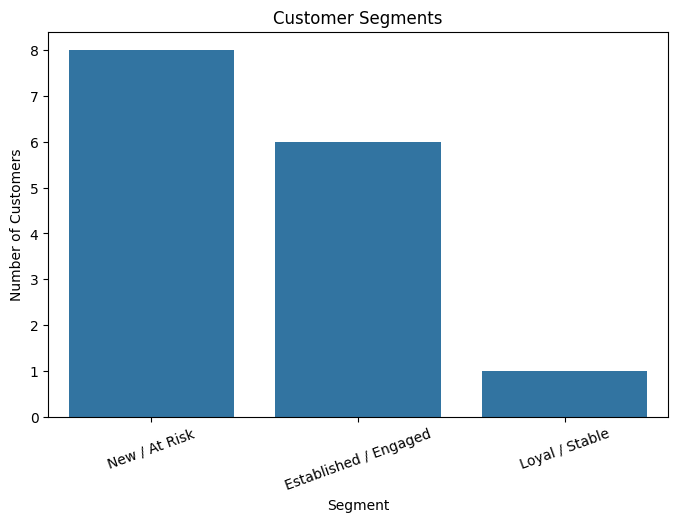

In [13]:
# Visualize customer segment sizes

plt.figure(figsize=(8, 5))

sns.countplot(
    data=segmentation_df,
    x="Segment",
    order=segmentation_df["Segment"].value_counts().index
)

plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)

plt.show()

In [14]:
# Define thresholds from the dataset

tenure_threshold = segmentation_df["TenureMonths"].median()
support_threshold = segmentation_df["SupportTickets"].median()
monthly_charge_threshold = segmentation_df["MonthlyCharges"].median()

print("Risk scoring thresholds:")
print("Tenure threshold:", tenure_threshold, "months")
print("Support ticket threshold:", support_threshold)
print("Monthly charge threshold:", monthly_charge_threshold)

Risk scoring thresholds:
Tenure threshold: 15.0 months
Support ticket threshold: 2.0
Monthly charge threshold: 79.99


In [15]:
# Calculate transparent rule-based churn risk score

def calculate_risk_score(row):

    score = 0

    # Short tenure
    if row["TenureMonths"] <= tenure_threshold:
        score += 3
    else:
        score -= 2

    # Contract type
    if row["ContractType"] == "Month-to-Month":
        score += 3
    else:
        score -= 2

    # Support interaction
    if row["SupportTickets"] > support_threshold:
        score += 2

    # Higher monthly charges
    if row["MonthlyCharges"] > monthly_charge_threshold:
        score += 1

    return score


segmentation_df["Risk Score"] = segmentation_df.apply(
    calculate_risk_score,
    axis=1
)

print("Risk scores calculated successfully!")

Risk scores calculated successfully!


In [16]:
# Assign risk levels based on the risk score

def assign_risk_level(score):

    if score >= 6:
        return "High Risk"
    elif score >= 3:
        return "Medium Risk"
    else:
        return "Low Risk"


segmentation_df["Risk Level"] = segmentation_df["Risk Score"].apply(
    assign_risk_level
)

print("Risk levels assigned successfully!")

Risk levels assigned successfully!


In [17]:
# Display customer-level risk assessment

risk_table = segmentation_df[
    [
        "CustomerID",
        "Segment",
        "TenureMonths",
        "ContractType",
        "SupportTickets",
        "MonthlyCharges",
        "Risk Score",
        "Risk Level",
        "Churn"
    ]
].sort_values(
    "Risk Score",
    ascending=False
)

risk_table

,CustomerID,Segment,TenureMonths,ContractType,SupportTickets,MonthlyCharges,Risk Score,Risk Level,Churn
0,CUST-1001,New / At Risk,12,Month-to-Month,3,49.99,8,High Risk,Yes
2,CUST-1003,New / At Risk,6,Month-to-Month,5,49.99,8,High Risk,Yes
4,CUST-1005,New / At Risk,8,Month-to-Month,4,79.99,8,High Risk,Yes
6,CUST-1007,New / At Risk,3,Month-to-Month,6,49.99,8,High Risk,Yes
13,CUST-1014,New / At Risk,2,Month-to-Month,5,49.99,8,High Risk,Yes
11,CUST-1012,New / At Risk,14,Month-to-Month,3,79.99,8,High Risk,Yes
9,CUST-1010,New / At Risk,4,Month-to-Month,4,49.99,8,High Risk,Yes
8,CUST-1009,New / At Risk,15,One Year,2,79.99,1,Low Risk,No
10,CUST-1011,Established / Engaged,30,Two Year,0,149.99,-3,Low Risk,No
3,CUST-1004,Established / Engaged,36,Two Year,0,149.99,-3,Low Risk,No


In [18]:
# Count customers by risk level

risk_distribution = segmentation_df["Risk Level"].value_counts()

print(risk_distribution)

Risk Level
Low Risk     8
High Risk    7
Name: count, dtype: int64


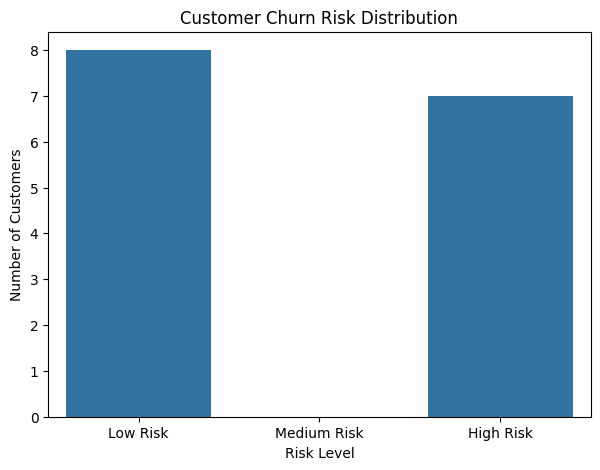

In [19]:
# Visualize customer risk levels

plt.figure(figsize=(7, 5))

sns.countplot(
    data=segmentation_df,
    x="Risk Level",
    order=["Low Risk", "Medium Risk", "High Risk"]
)

plt.title("Customer Churn Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")

plt.show()

In [20]:
# Compare predicted risk level with actual churn

risk_vs_churn = pd.crosstab(
    segmentation_df["Risk Level"],
    segmentation_df["Churn"],
    margins=True
)

risk_vs_churn

Churn,No,Yes,All
Risk Level,,,
High Risk,0,7,7
Low Risk,8,0,8
All,8,7,15


In [21]:
# Calculate actual churn rate for each risk level

risk_churn_rate = (
    segmentation_df
    .groupby("Risk Level")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reindex(["Low Risk", "Medium Risk", "High Risk"])
)

risk_churn_rate

,Churn
Risk Level,
Low Risk,0.0
Medium Risk,NaN
High Risk,100.0


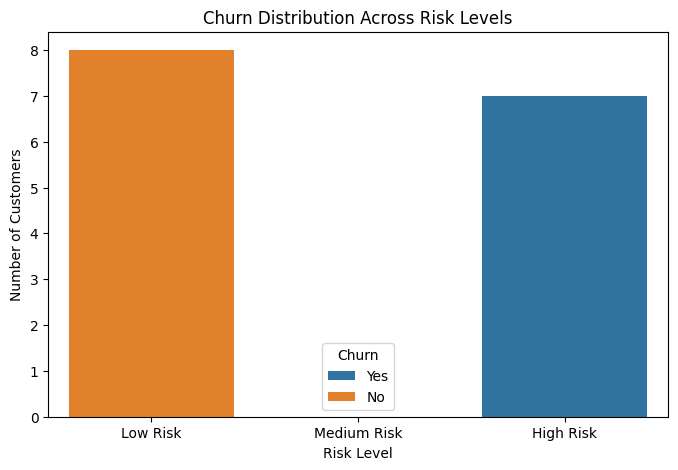

In [22]:
# Create a risk-level vs churn visualization

plt.figure(figsize=(8, 5))

sns.countplot(
    data=segmentation_df,
    x="Risk Level",
    hue="Churn",
    order=["Low Risk", "Medium Risk", "High Risk"]
)

plt.title("Churn Distribution Across Risk Levels")
plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")

plt.show()

In [23]:
# Generate customer-level recommendations

def generate_recommendation(row):

    if row["Risk Level"] == "High Risk":
        return "Immediate retention outreach and personalized offer"

    elif row["Risk Level"] == "Medium Risk":
        return "Proactive engagement and contract upgrade offer"

    else:
        return "Maintain engagement and loyalty benefits"


segmentation_df["Recommendation"] = segmentation_df.apply(
    generate_recommendation,
    axis=1
)

print("Recommendations generated successfully!")

Recommendations generated successfully!


In [24]:
# Create final customer segment and recommendation table

final_segment_table = segmentation_df[
    [
        "CustomerID",
        "Segment",
        "Risk Score",
        "Risk Level",
        "Recommendation"
    ]
].sort_values(
    "Risk Score",
    ascending=False
)

final_segment_table

,CustomerID,Segment,Risk Score,Risk Level,Recommendation
0,CUST-1001,New / At Risk,8,High Risk,Immediate retention outreach and personalized ...
2,CUST-1003,New / At Risk,8,High Risk,Immediate retention outreach and personalized ...
4,CUST-1005,New / At Risk,8,High Risk,Immediate retention outreach and personalized ...
6,CUST-1007,New / At Risk,8,High Risk,Immediate retention outreach and personalized ...
13,CUST-1014,New / At Risk,8,High Risk,Immediate retention outreach and personalized ...
11,CUST-1012,New / At Risk,8,High Risk,Immediate retention outreach and personalized ...
9,CUST-1010,New / At Risk,8,High Risk,Immediate retention outreach and personalized ...
8,CUST-1009,New / At Risk,1,Low Risk,Maintain engagement and loyalty benefits
10,CUST-1011,Established / Engaged,-3,Low Risk,Maintain engagement and loyalty benefits
3,CUST-1004,Established / Engaged,-3,Low Risk,Maintain engagement and loyalty benefits


In [25]:
# Summarize each customer segment

segment_summary = (
    segmentation_df
    .groupby("Segment")
    .agg(
        Customers=("CustomerID", "count"),
        Average_Tenure=("TenureMonths", "mean"),
        Average_Monthly_Charges=("MonthlyCharges", "mean"),
        Average_Support_Tickets=("SupportTickets", "mean"),
        Average_Risk_Score=("Risk Score", "mean")
    )
    .round(2)
)

segment_summary

,Customers,Average_Tenure,Average_Monthly_Charges,Average_Support_Tickets,Average_Risk_Score
Segment,,,,,
Established / Engaged,6,33.33,121.66,0.67,-3.33
Loyal / Stable,1,18.00,49.99,2.00,-4.00
New / At Risk,8,8.00,61.24,4.00,7.12


In [26]:
# Summarize customers by risk level

risk_summary = (
    segmentation_df
    .groupby("Risk Level")
    .agg(
        Customers=("CustomerID", "count"),
        Average_Tenure=("TenureMonths", "mean"),
        Average_Monthly_Charges=("MonthlyCharges", "mean"),
        Average_Support_Tickets=("SupportTickets", "mean"),
        Average_Risk_Score=("Risk Score", "mean")
    )
    .reindex(["Low Risk", "Medium Risk", "High Risk"])
    .round(2)
)

risk_summary

,Customers,Average_Tenure,Average_Monthly_Charges,Average_Support_Tickets,Average_Risk_Score
Risk Level,,,,,
Low Risk,8.0,29.12,107.49,1.00,-2.88
Medium Risk,NaN,NaN,NaN,NaN,NaN
High Risk,7.0,7.00,58.56,4.29,8.00


In [27]:
# Save the final segmentation and recommendation table

final_segment_table.to_csv(
    "customer_segmentation_recommendations.csv",
    index=False
)

print("File saved successfully!")

File saved successfully!


In [28]:
from google.colab import files

files.download("customer_segmentation_recommendations.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>